In [1]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

g:\Genarative-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
from langchain_community.document_loaders import PyPDFLoader

In [3]:
docs = (
    PyPDFLoader('.\Document\Company_Policies.pdf').load() +
    PyPDFLoader('.\Document\Company_Profile.pdf').load() +
    PyPDFLoader('.\Document\Product_and_Pricing.pdf').load()
    
)

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hmaru\AppData\Local\Temp\ipykernel_7172\2514151863.py:2: SyntaxWarning: invalid escape sequence '\D'
  PyPDFLoader('.\Document\Company_Policies.pdf').load() +
C:\Users\hmaru\AppData\Local\Temp\ipykernel_7172\2514151863.py:3: SyntaxWarning: invalid escape sequence '\D'
  PyPDFLoader('.\Document\Company_Profile.pdf').load() +
C:\Users\hmaru\AppData\Local\Temp\ipykernel_7172\2514151863.py:4: SyntaxWarning: invalid escape sequence '\D'
  PyPDFLoader('.\Document\Product_and_Pricing.pdf').load()
incorrect startxref pointer(1)
parsing for Object Streams
incorrect startxref pointer(1)
parsing for Object Streams
incorrect startxref pointer(1)
parsing for Object Streams


In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size = 600,chunk_overlap = 150).split_documents(docs)
print(len(chunks))

16


In [7]:
embed_model = HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2210.30it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
vector_store = FAISS.from_documents(chunks,embed_model)
retriever = vector_store.as_retriever(search_type = 'similarity',search_kwargs={'k':4})

In [9]:
import os
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY")
)

In [10]:
from typing import Annotated, TypedDict
class State(TypedDict):
    question:str

    retrieval_query: str
    rewrite_tries: int

    need_retrieval:bool

    docs:list[Document]
    relevant_docs:list[Document]
    context:str

    issup:Literal["fully_supported","partially_supported","no_support"]
    evidence:list[str]

    isuse: Literal['useful','not_useful']
    use_reason: str
    
    retries: int
    out:list
    answer: Annotated[str, lambda old, new: new]

In [11]:
from langchain_core.output_parsers import StrOutputParser
class RetrieveDecision(BaseModel):
    should_retrieve:bool = Field(
        ...,
        description = "True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}")
    ]
)

retrieve_decied_chain = decide_retrieval_prompt | llm.with_structured_output(
    RetrieveDecision,
    method="json_mode"  
)
def decide_retrieval_node(state: State):
    decision:RetrieveDecision = retrieve_decied_chain.invoke({'question':state['question']})

    return {'need_retrieval':decision.should_retrieve}

In [74]:
class Isrelevant(BaseModel):
    is_relevant:bool = Field(
        ...,
        description='True if the document helps answer the question, else False.'
    )

Isrelevant_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',
        "You are judging document relevance.\n"
        "Return JSON that matches this schema:\n"
        "{{'is_relevant': boolean}}\n\n"
        "RULES:\n"
        "1. A document is relevant if it contains information useful for answering the question.\n"
        "2. ENTITY CHECK: If the question asks about a specific company/product (e.g., 'DiplomaAI') and the document is about a completely different company (e.g., 'NexaAI'), the document is NOT relevant. Return {{'is_relevant': false}}.\n"
        ),
        ('human','\nQuestion: {question}\n\nDocument:\n{document}')
    ]
)


isrelevant_chain = Isrelevant_prompt | llm.with_structured_output(Isrelevant,method='json_mode') 

def isrelevant_node(state:State):
    docs = state['docs']
    qus = state['question']
    all_docs = []
    all_docs_input = []
    relevanced_doc:list[Document] = []

    for d  in docs:
       
        all_docs_input.append({'question':qus,'document':d.page_content})
    
    all_docs_out = isrelevant_chain.batch(all_docs_input)

    for d,r in zip(docs,all_docs_out):
        if r.is_relevant:
            relevanced_doc.append(d)

    return {
        'relevant_docs': relevanced_doc,
        'out':all_docs_out
        
        }
        


In [75]:
generation_prompt = ChatPromptTemplate.from_messages([
     (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", '\nQuestion: {question}')]
        
)

genaration_chain = generation_prompt | llm | StrOutputParser()

def generation_node(state:State):
    out = genaration_chain.invoke({'question':state['question']})
    return {'answer': out, 'context': ''}

In [76]:
main_generation_prompt = ChatPromptTemplate.from_messages(
    [
         ('system',
        "You are a strict business RAG assistant.\n"
        "Answer the user's question using ONLY the provided context.\n"
        "RULES:\n"
        "1. Compare the entities (like company names) in the Question and the Context. If the Question asks about a specific entity (e.g., DiplomaAI) but the Context is about a different entity (e.g., NexaAI), you MUST say: 'No relevant document found.'\n"
        "2. When generating your answer, ALWAYS explicitly mention the specific entity/company name from the context (e.g., say 'Aarav Mehta is the CEO of NexaAI' instead of just 'Aarav Mehta is the CEO').\n"
        "3. Do not use outside knowledge.\n"
        ),   
        ('human','\nquestion:{question}\n\ndocument:{context}')
    ]
)

main_generation_chain = main_generation_prompt | llm | StrOutputParser()

def main_generation_node(state:State):
    qus = state['question']
    docs = state.get('relevant_docs',[])

    context = "\n\n---\n\n".join(d.page_content for d in docs).strip()
    if not context:
        return{'answer':"I dont Know,No relevant document found", 'context': ''}
        
    ans = main_generation_chain.invoke({'question':qus,'context':context})
    return {
        'answer':ans,
        'context':context
        }

In [77]:
def no_relevant_docs(state:State):
    return{'answer':"I dont Know,No relevant document found", 'context': ''}


In [78]:
class IsSupDecision(BaseModel):
    issup: Literal["fully_supported","partially_supported","no_support"]
    evidence: list[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate([
    ('system',
    "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: list up to 3 short direct quotes from CONTEXT as plain strings only. Each evidence item MUST be a string, not an object or dict.\n"
            "- Do not use outside knowledge."
            "- Entity check: If the ANSWER contains a company name, product name, or proper noun "
            "that does NOT appear in CONTEXT, classify as no_support immediately.\n"
            "- Entity Check: Compare the entities in the ANSWER and the CONTEXT. If the ANSWER assigns properties to an entity from the QUESTION that does not exist in the CONTEXT, or if the ANSWER hides the specific company name to appear correct, choose no_support.\n"
            ),
    (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        )
])

issup_chain = issup_prompt | llm.with_structured_output(IsSupDecision,method='json_mode')

def issup_node(state:State):
    qus =  state['question']
    answer = state['answer']
    context = state.get('context', '')  # safe get

    if not context:
        return {
            'issup': 'no_support',
            'evidence': []
        }

    decision:IsSupDecision = issup_chain.invoke({'question':qus,'answer':answer,'context':context})
    return {
        'issup':decision.issup,
        'evidence':decision.evidence
    }

In [79]:
revise_prompt = ChatPromptTemplate([
    (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            'human',
            'Question:\n{question}\n\ncurrent answer:\n{answer}\n\ncontext:\n{context}'
        )
])

revise_chain = revise_prompt | llm | StrOutputParser()

def revise_node(state:State):
    current_ans = state['answer']
    qus = state['question']
    context = state.get('context', '')

    out = revise_chain.invoke({'question':qus,'answer':current_ans,'context':context})

    return {
        'answer':out,
        'retries':state.get('retries',0) + 1 
    }

In [80]:
class IsUse(BaseModel):
    isuse: Literal['useful','not_useful'] 
    use_reason: str = Field(...,description='Short reason in 1 line')

isuse_prompt = ChatPromptTemplate.from_messages([
    (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
            "- not_useful: The answer is generic, off-topic, or talks about a DIFFERENT entity/company than what the user explicitly asked for in the question.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        )
])

isuse_chain = isuse_prompt | llm.with_structured_output(IsUse)

def isuse_node(state:State):
    qus = state.get('question','')
    ans = state.get('answer','')
    decision:IsUse = isuse_chain.invoke({'question':qus,'answer':ans})

    return {
        'isuse': decision.isuse,
        'use_reason': decision.use_reason
    }

max_rewrite_tries = 3

def route_after_isuse(state:State) -> Literal['finalize','rewrite','no_answer_found']:
    if state.get('isuse') == 'useful' :
        return 'finalize'

    if state.get('isuse') == 'not_useful' and state.get('rewrite_tries',0) < max_rewrite_tries:
        return 'rewrite'
    
    return 'no_answer_found'

In [81]:
def accept_answer_node(state:State):
    return {}

In [82]:
def no_answer_found_node(state:State):
    return {'answer':'No answer found, because answer is not use full'}

In [83]:
def retrieve_node(state:State):
    q = state.get('retrieval_query') or state['question']
    return {'docs':retriever.invoke(q)}

In [84]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
        )
    

rewrite_prompt = ChatPromptTemplate.from_messages([
  (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
])

rewrite_chain = rewrite_prompt | llm.with_structured_output(RewriteDecision)

def rewrite_node(state:State):
    out:RewriteDecision = rewrite_chain.invoke({
        'question':state['question'],
        'retrieval_query': state.get('retrieval_query',''),
        'answer': state.get('answer','')
        
        })

    return {
        'retrieval_query':out.retrieval_query,
        'rewrite_tries': state.get('rewrite_tries',0) + 1
        
    }

In [85]:
def route_after_relevance(state:State) ->Literal['main_generation_node','no_relevant_docs']:
    if state.get('relevant_docs') and len(state.get('relevant_docs')) > 0:
        return "main_generation_node"
    return "no_relevant_docs"


In [86]:
def route_after_decide(state:State) -> Literal['generate_direct','retrieve']:
    if state['need_retrieval']:
        return 'retrieve'
    return 'generate_direct'


In [87]:
max_retries = 4

def route_after_issup(state:State) -> Literal['accept_answer','revise_answer','no_answer_found_node']:
    if state.get('issup') == 'fully_supported':
        return 'accept_answer'

    if state.get('retries',0) >= max_retries:
        return 'no_answer_found_node'
    return 'revise_answer'

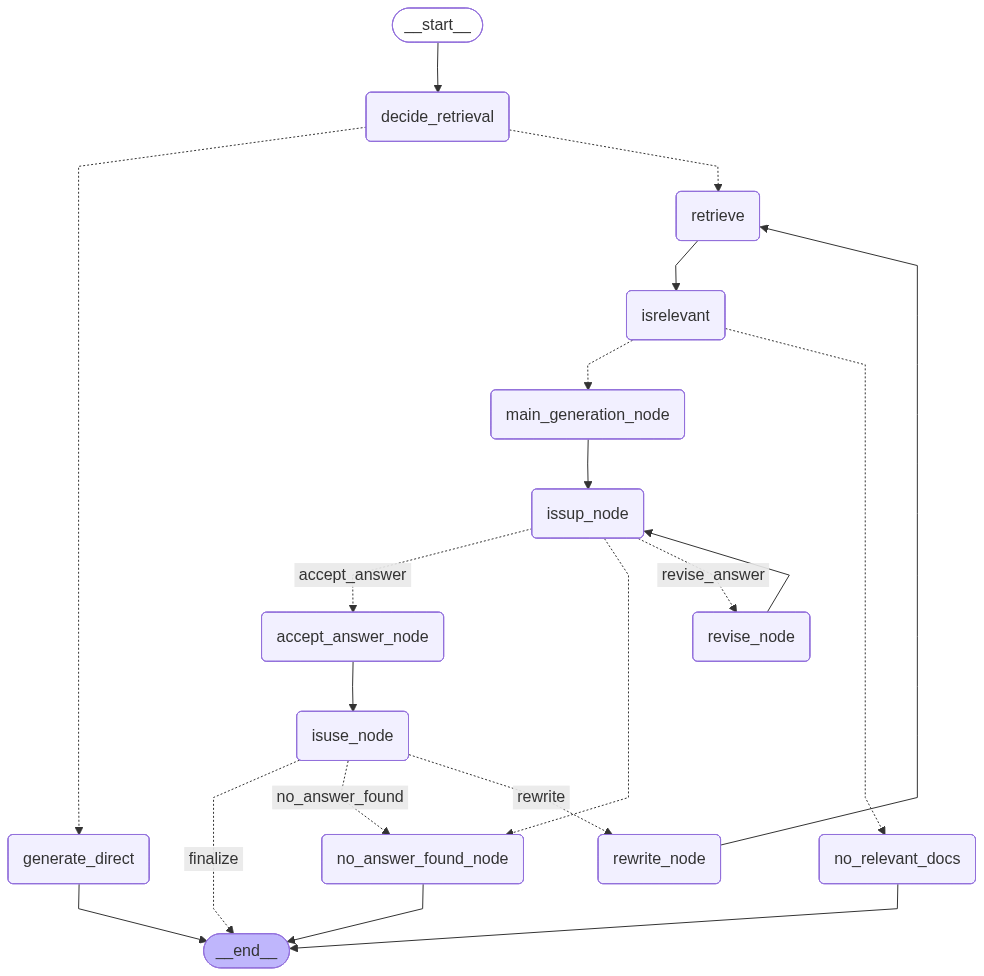

In [88]:
g = StateGraph(State)

# --------------------
# Nodes
# --------------------
g.add_node("decide_retrieval", decide_retrieval_node)
g.add_node("generate_direct", generation_node)
g.add_node("retrieve", retrieve_node)
g.add_node('isrelevant',isrelevant_node)
g.add_node('main_generation_node',main_generation_node)
g.add_node("issup_node",issup_node)
g.add_node('revise_node',revise_node)
g.add_node('accept_answer_node',accept_answer_node)
g.add_node('isuse_node',isuse_node)
g.add_node('no_answer_found_node',no_answer_found_node)
g.add_node('no_relevant_docs', no_relevant_docs) 
g.add_node('rewrite_node',rewrite_node)





g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)
g.add_edge('retrieve','isrelevant')

g.add_conditional_edges(
    'isrelevant',
    route_after_relevance,
    {'no_relevant_docs':'no_relevant_docs','main_generation_node':'main_generation_node'}
    )

g.add_edge("main_generation_node",'issup_node') 

g.add_conditional_edges(
    'issup_node',
    route_after_issup,
    {'accept_answer':'accept_answer_node','revise_answer':'revise_node','no_answer_found_node':'no_answer_found_node'}
)

g.add_edge('revise_node','issup_node')
g.add_edge('accept_answer_node','isuse_node') 

g.add_conditional_edges(
    'isuse_node',
    route_after_isuse,
    {
        'finalize': END,
        'rewrite':'rewrite_node',
        'no_answer_found':'no_answer_found_node'
    }
    )
g.add_edge('rewrite_node','retrieve')
g.add_edge('no_answer_found_node',END)
g.add_edge('no_relevant_docs', END)



app = g.compile()
app


In [95]:
result = app.invoke(
    {
        "question": "who is varav kehta",
        "need_retrieval": False,
        'relevant_docs':'',
        "docs": [],
        'retries':0,
        'issup': '',
        'evidence':'',
        "answer": "",
        'isuse': '',
        'use_reason':''
    }
)

print('need retrieval: ',result['need_retrieval'])
print('len: ',len(result['docs']))
print('relevant docs: ',result['relevant_docs'])
print('relevant docs len: ',len(result['relevant_docs']))
print('issup: ',result['issup'])
print('evidence: ',result['evidence'])
print('retries: ',result['retries'])
print('answer: ',result['answer'])
print('isuse: ',result['isuse'])
print('isuse reason: ',result['use_reason'])






need retrieval:  True
len:  4
relevant docs:  [Document(id='41534387-c322-4420-b40e-1a48e7b93c12', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': '.\\Document\\Company_Profile.pdf', 'total_pages': 2, 'page': 1, 'page_label': '2'}, page_content='Founder\nAarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and\ncloud infrastructure.\nHe previously worked with global consulting firms where he led multiple large-scale digital\ntransformation projects.\nLeadership Team\nThe leadership team brings experience across AI engineering, product management, and business\noperations.\n\x7f\nAarav Mehta – CEO & Founder\n\x7f\nRiya Kapoor – CTO (Distributed systems & AI platforms)\n\x7f\nKunal Sharma – Head of P